<ipython-input-3-59c9421a87fe>:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


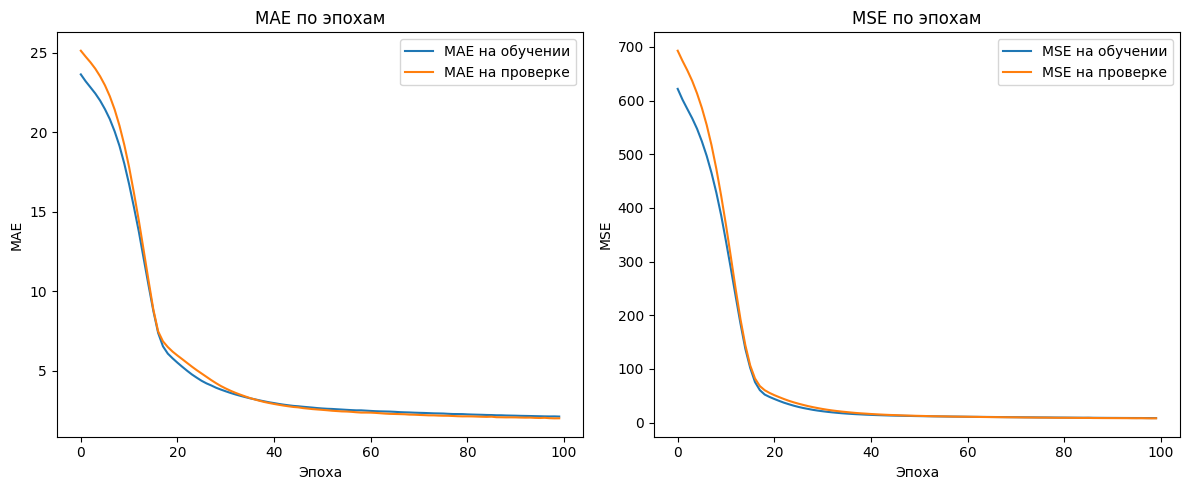

Test MAE: 2.04
Test MSE: 8.17
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


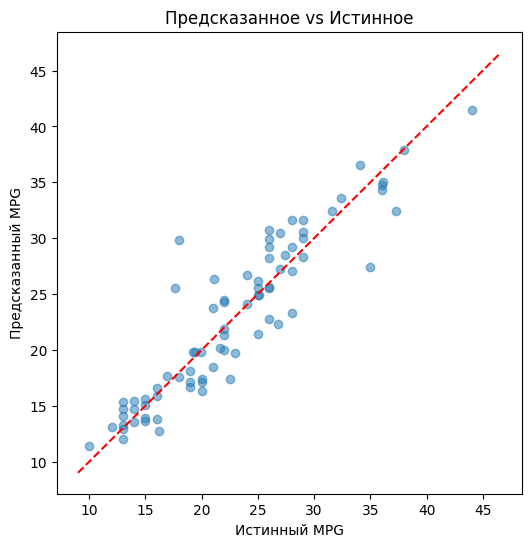

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Загрузка данных Auto MPG
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']
# Используем delim_whitespace=True для корректного разделения столбцов
df = pd.read_csv(
    url, names=column_names, na_values='?', comment='\t',
    delim_whitespace=True
)

# Удаляем строки с пропусками
df.dropna(inplace=True)

# Отбрасываем колонку car_name
df.drop('car_name', axis=1, inplace=True)

# 2. Разделение на X и y
X = df.drop('mpg', axis=1).values
y = df['mpg'].values

# Проверка на количество записей\ n
if X.shape[0] == 0:
    raise ValueError("Датасет пуст. Проверьте загрузку данных.")

# 3. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Масштабирование признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 5. Построение модели для регрессии
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # выходной нейрон без активации для регрессии
])

model.compile(
    optimizer='adam',
    loss='mse',           # MSE для регрессии
    metrics=['mae', 'mse']
)

# 6. Обучение модели
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# 7. Визуализация метрик обучения
plt.figure(figsize=(12, 5))

# MAE
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='MAE на обучении')
plt.plot(history.history['val_mae'], label='MAE на проверке')
plt.title('MAE по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()

# MSE
plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='MSE на обучении')
plt.plot(history.history['val_mse'], label='MSE на проверке')
plt.title('MSE по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

# 8. Оценка на тестовой выборке
test_metrics = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {test_metrics[1]:.2f}")
print(f"Test MSE: {test_metrics[2]:.2f}")

# 9. Сравнение предсказаний и истинных значений
y_pred = model.predict(X_test).flatten()
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Истинный MPG')
plt.ylabel('Предсказанный MPG')
plt.title('Предсказанное vs Истинное')
plt.show()
